6_1

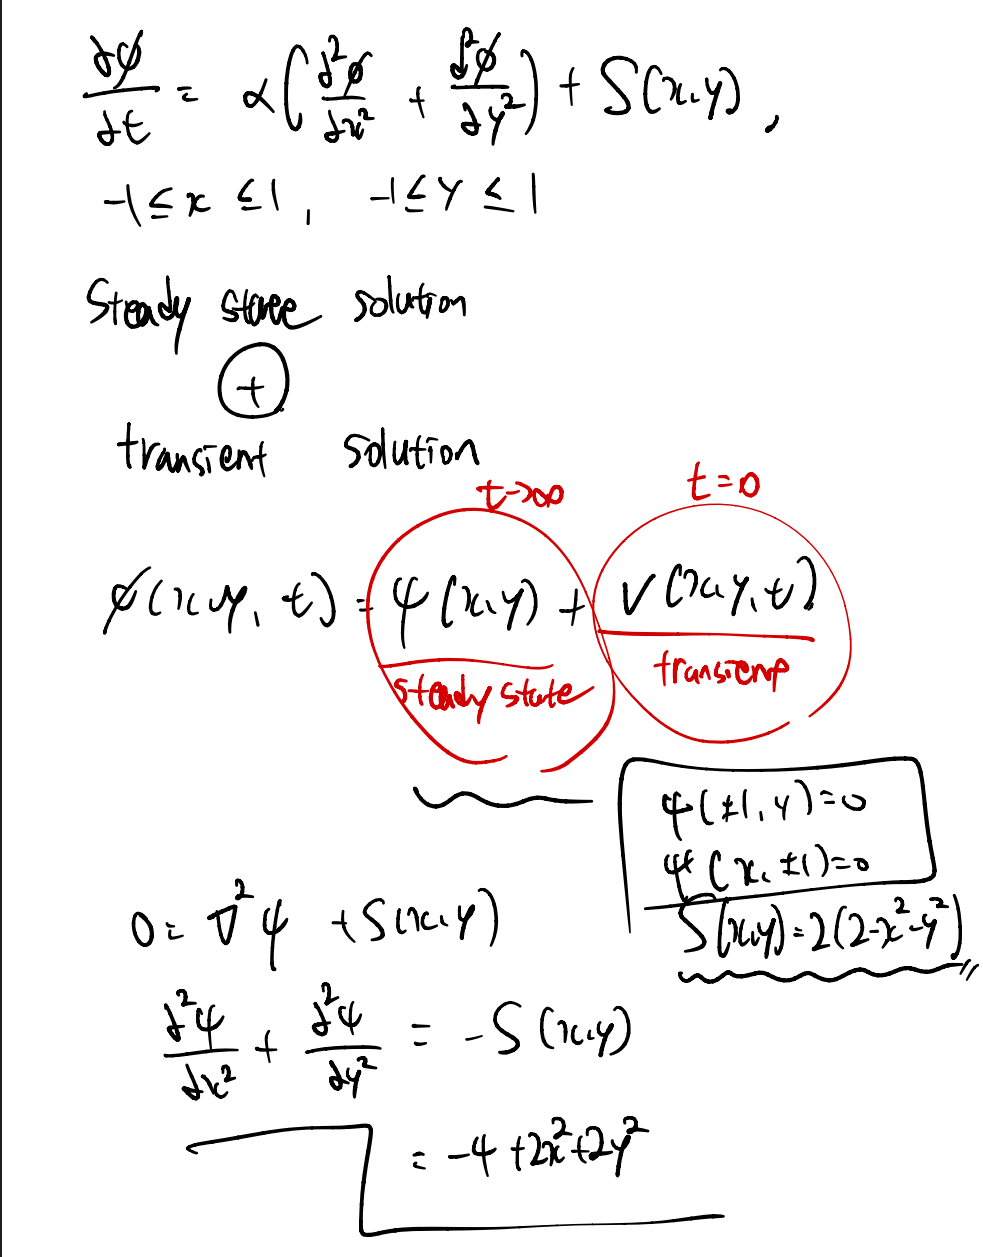
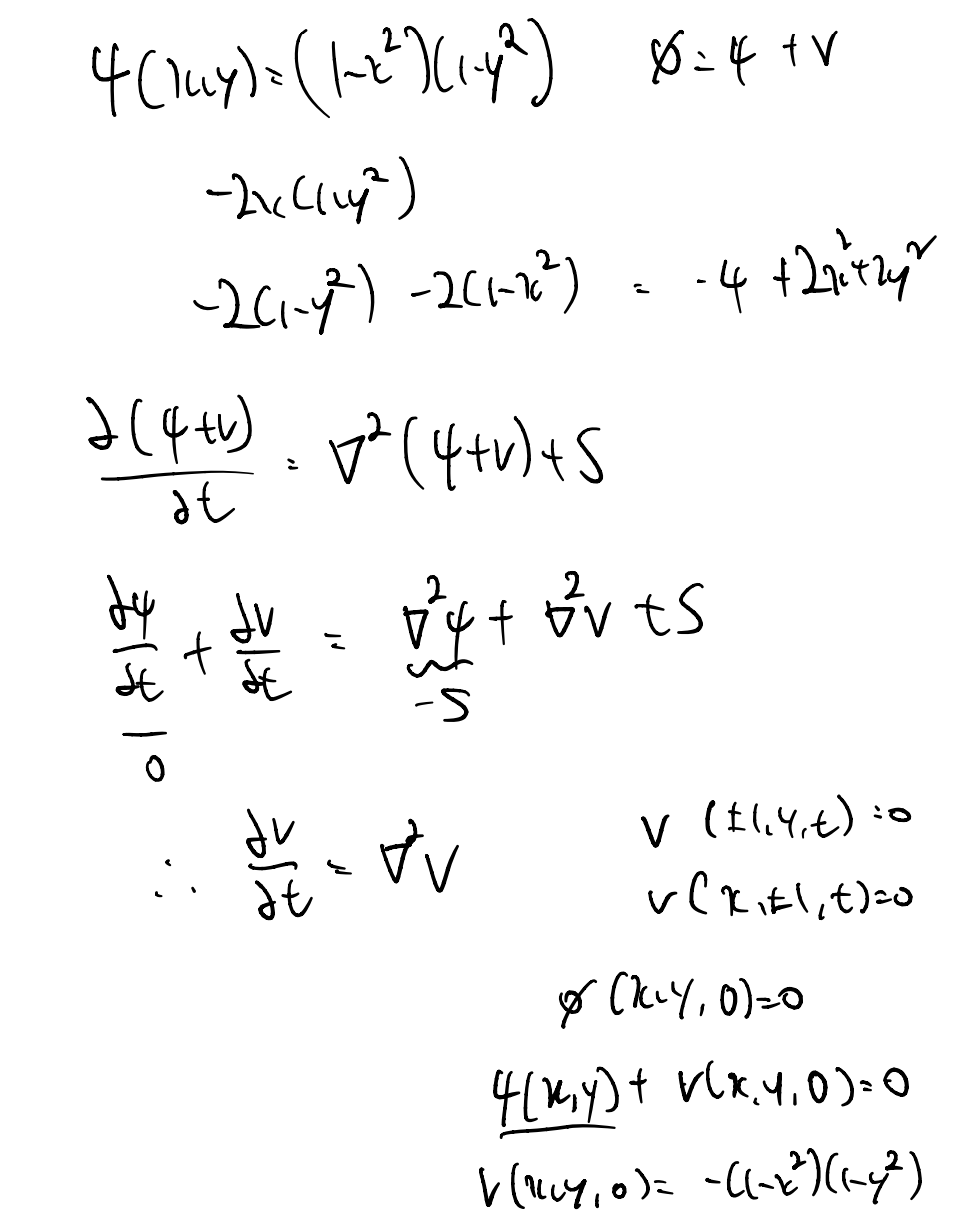
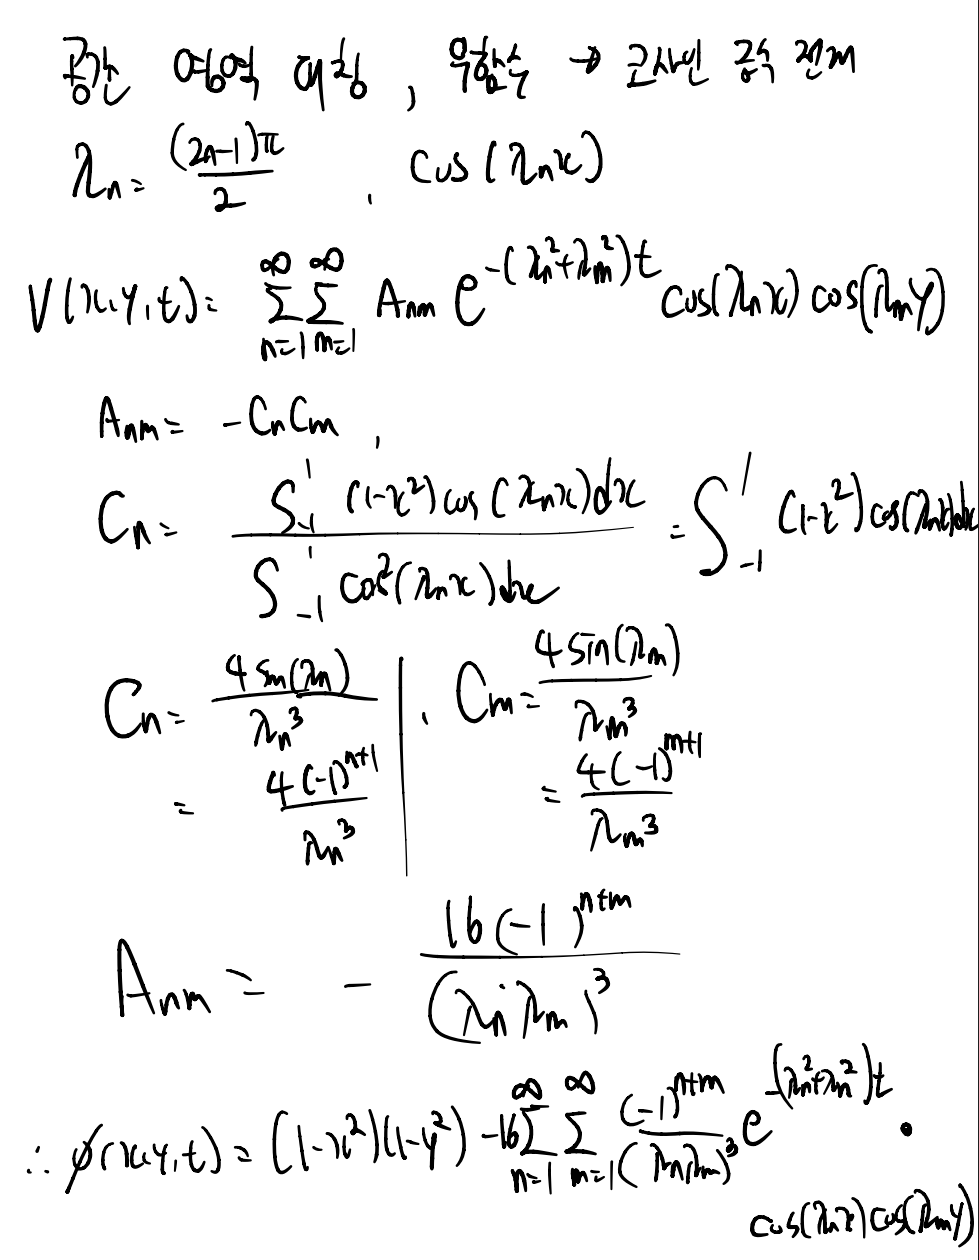

6_2


[Case 1: N=10 실행]
Simulation Start: N=10, dt=0.1, Steps=30
-> Calculation Done. Max Temp: 1.000000

[Case 2: N=50 실행]
Simulation Start: N=50, dt=0.05, Steps=60
-> Calculation Done. Max Temp: 1.000000


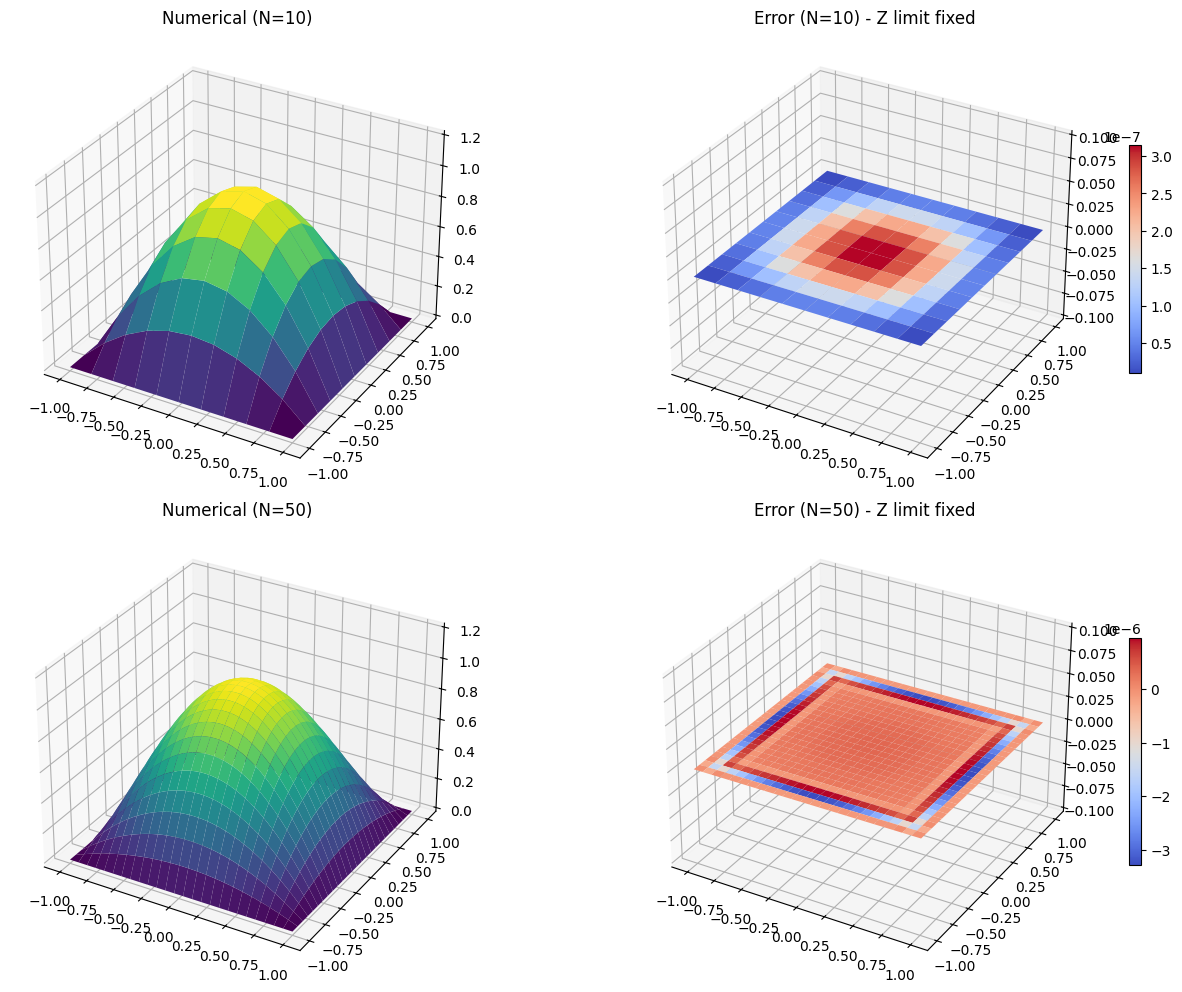

------------------------------
Case 1 (N=10) Max Error: 3.34759e-07
Case 2 (N=50) Max Error: 1.55170e-05


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 솔버 함수 정의 (Dense Matrix 방식 - 디버깅용) ---
def solve_steady_state_cn_debug(N, M, dt, t_final=3.0):
    x = np.linspace(-1, 1, N+1)
    y = np.linspace(-1, 1, M+1)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = np.meshgrid(x, y)
    
    # Source Term 및 Exact Solution
    S = 2 * (2 - X**2 - Y**2)
    Exact = (1 - X**2) * (1 - Y**2)
    
    nx, ny = N-1, M-1
    num_interior = nx * ny
    
    # --- 행렬 생성 (Dense Matrix) ---
    # X 방향 미분 행렬
    main_diag_x = -2 * np.ones(num_interior)
    off_diag_x = np.ones(num_interior - 1)
    for i in range(1, num_interior):
        if i % nx == 0:
            off_diag_x[i-1] = 0     
    D2x = (np.diag(main_diag_x) + np.diag(off_diag_x, 1) + np.diag(off_diag_x, -1)) / dx**2
    
    # Y 방향 미분 행렬
    main_diag_y = -2 * np.ones(num_interior)
    off_diag_y = np.ones(num_interior - nx)
    D2y = (np.diag(main_diag_y) + np.diag(off_diag_y, nx) + np.diag(off_diag_y, -nx)) / dy**2
    
    L = D2x + D2y # Laplacian

    # Crank-Nicolson Matrices
    I = np.eye(num_interior)
    A = I - 0.5 * dt * L
    B = I + 0.5 * dt * L
    
    S_interior = S[1:-1, 1:-1].flatten()
    u = np.zeros(num_interior)
    
    steps = int(t_final / dt)
    print(f"Simulation Start: N={N}, dt={dt}, Steps={steps}") 
    
    for i in range(steps):
        rhs = np.dot(B, u) + dt * S_interior
        u = np.linalg.solve(A, rhs)
        
    U_final = np.zeros((M+1, N+1))
    U_final[1:-1, 1:-1] = u.reshape((ny, nx))
    
    print(f"-> Calculation Done. Max Temp: {np.max(U_final):.6f}")
    
    return X, Y, U_final, Exact

# --- 2. 계산 실행 ---

# Case 1: N=10 (성긴 격자)
print("\n[Case 1: N=10 실행]")
N1, M1, dt1 = 10, 10, 0.1
X1, Y1, U1, Exact1 = solve_steady_state_cn_debug(N1, M1, dt1)

# Case 2: N=50 (적당히 촘촘한 격자)
# N=50이면 격자점(내부)은 약 2,400개 행렬 크기는 2400x2400 입니다.
# 이 정도면 일반 PC에서 1~5초 내외로 계산 가능합니다.
print("\n[Case 2: N=50 실행]")
N2, M2, dt2 = 50, 50, 0.05 
X2, Y2, U2, Exact2 = solve_steady_state_cn_debug(N2, M2, dt2)


# --- 3. 그래프 그리기 ---
fig = plt.figure(figsize=(14, 10))

# [상단] Case 1: N=10
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot_surface(X1, Y1, U1, cmap='viridis')
ax1.set_title(f'Numerical (N={N1})')
ax1.set_zlim(0, 1.2)

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
# 오차 계산
Error1 = Exact1 - U1
surf2 = ax2.plot_surface(X1, Y1, Error1, cmap='coolwarm')
ax2.set_title(f'Error (N={N1}) - Z limit fixed')
ax2.set_zlim(-0.1, 0.1) # 오차가 0에 가까움을 보여주기 위해 범위 고정
fig.colorbar(surf2, ax=ax2, shrink=0.5)

# [하단] Case 2: N=50
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot_surface(X2, Y2, U2, cmap='viridis')
ax3.set_title(f'Numerical (N={N2})')
ax3.set_zlim(0, 1.2)

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
# 오차 계산
Error2 = Exact2 - U2
surf4 = ax4.plot_surface(X2, Y2, Error2, cmap='coolwarm')
ax4.set_title(f'Error (N={N2}) - Z limit fixed')
ax4.set_zlim(-0.1, 0.1) # 오차가 0에 가까움을 보여주기 위해 범위 고정
fig.colorbar(surf4, ax=ax4, shrink=0.5)

plt.tight_layout()
plt.show()

# 최종 텍스트 출력
print("-" * 30)
print(f"Case 1 (N={N1}) Max Error: {np.max(np.abs(Error1)):.5e}")
print(f"Case 2 (N={N2}) Max Error: {np.max(np.abs(Error2)):.5e}")

6_3

      Heat Equation Solver - Order of Accuracy Analysis   

1. [Spatial Accuracy] Fixed dt, Varying N (vs Exact Solution)
N     | dx         | Error           | Ratio     
--------------------------------------------------
10    | 0.20000    | 2.42389e-02     | -         
20    | 0.10000    | 6.65174e-03     | 3.64      
40    | 0.05000    | 1.65992e-03     | 4.01      
80    | 0.02500    | 4.14792e-04     | 4.00      

2. [Temporal Accuracy] Fixed N, Varying dt (vs Reference)
   Calculating Reference Solution (dt=0.0001)...
dt    | Error (vs Ref)  | Ratio     
--------------------------------------------------
0.2   | 9.32607e-05     | -         
0.1   | 1.99371e-05     | 4.68      
0.05  | 4.98806e-06     | 4.00      
0.025 | 1.24723e-06     | 4.00      


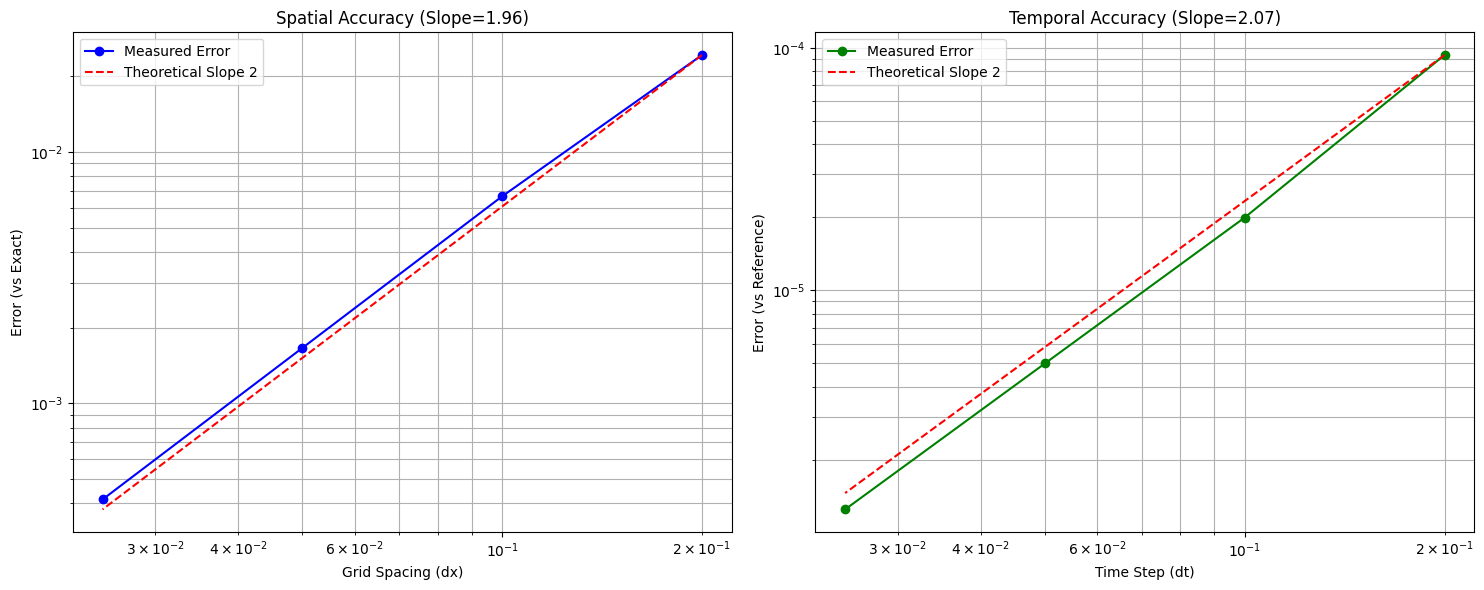


Final Analysis Result:
Spatial Slope  : 1.9609 (Target: 2.0)
Temporal Slope : 2.0672  (Target: 2.0)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

# ==========================================
# 1. 통합 솔버 함수 (Crank-Nicolson)
# ==========================================
def solve_heat_equation(N, dt, t_target):
    """
    N: 격자 수
    dt: 시간 간격
    t_target: 목표 시간
    Returns: U_final (2D array)
    """
    # Grid 생성
    x = np.linspace(-1, 1, N+1)
    y = np.linspace(-1, 1, N+1)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = np.meshgrid(x, y)
    
    nx, ny = N-1, N-1
    num_interior = nx * ny
    
    # Exact Solution & Source Term (Time-dependent Sine Wave)
    # u(x,y,t) = e^(-t) * sin(pi*x) * sin(pi*y)
    def get_exact_func(t):
        return np.exp(-t) * np.sin(np.pi * X) * np.sin(np.pi * Y)
    
    def get_source_func(t):
        # Heat Eq: u_t = Laplacian(u) + S
        # S = (2*pi^2 - 1) * u
        return (2 * np.pi**2 - 1) * get_exact_func(t)

    # 행렬 생성 (Dense Matrix for simplicity)
    main_diag = -2 * np.ones(num_interior)
    off_diag = np.ones(num_interior - 1)
    for i in range(1, num_interior):
        if i % nx == 0: off_diag[i-1] = 0
            
    D2x = (np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)) / dx**2
    
    main_diag_y = -2 * np.ones(num_interior)
    off_diag_y = np.ones(num_interior - nx)
    D2y = (np.diag(main_diag_y) + np.diag(off_diag_y, nx) + np.diag(off_diag_y, -nx)) / dy**2
    
    L = D2x + D2y # Laplacian Matrix

    # Crank-Nicolson System matrices
    I = np.eye(num_interior)
    A = I - 0.5 * dt * L
    B = I + 0.5 * dt * L
    
    # 초기 조건 및 설정
    u = get_exact_func(0)[1:-1, 1:-1].flatten()
    t_current = 0
    steps = int(np.round(t_target / dt))
    
    # 고속 연산을 위한 LU 분해
    lu, piv = scipy.linalg.lu_factor(A)
    
    # Time Stepping
    for _ in range(steps):
        # Source term 평균 (Crank-Nicolson)
        S_avg = 0.5 * (get_source_func(t_current) + get_source_func(t_current + dt))
        S_vec = S_avg[1:-1, 1:-1].flatten()
        
        rhs = np.dot(B, u) + dt * S_vec
        u = scipy.linalg.lu_solve((lu, piv), rhs)
        t_current += dt
        
    # 결과 복원
    U_final = np.zeros((N+1, N+1))
    U_final[1:-1, 1:-1] = u.reshape((ny, nx))
    
    return U_final, X, Y, get_exact_func # X, Y, 함수도 리턴 (분석용)


# ==========================================
# 2. Main Analysis Execution
# ==========================================
print("==========================================================")
print("      Heat Equation Solver - Order of Accuracy Analysis   ")
print("==========================================================\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --------------------------------------------------------
# Part 1: Spatial Accuracy (공간 정확도)
# 전략: dt를 고정하고, N을 변화시킴. 비교 대상: 참값(Exact)
# --------------------------------------------------------
print("1. [Spatial Accuracy] Fixed dt, Varying N (vs Exact Solution)")
N_list = [10, 20, 40, 80]
dt_fixed = 1e-4  # 시간 오차 무시용 (아주 작게)
t_target_space = 0.1
space_errors = []
dx_list = []

print(f"{'N':<5} | {'dx':<10} | {'Error':<15} | {'Ratio':<10}")
print("-" * 50)

for i, N in enumerate(N_list):
    U_num, X, Y, ExactFunc = solve_heat_equation(N, dt_fixed, t_target_space)
    U_exact = ExactFunc(t_target_space)
    
    err = np.max(np.abs(U_num - U_exact))
    space_errors.append(err)
    dx = 2.0 / N
    dx_list.append(dx)
    
    ratio_str = "-"
    if i > 0:
        ratio = space_errors[i-1] / space_errors[i]
        ratio_str = f"{ratio:.2f}"
    
    print(f"{N:<5} | {dx:<10.5f} | {err:<15.5e} | {ratio_str:<10}")

# 그래프 1 (Space)
ax1.loglog(dx_list, space_errors, 'bo-', label='Measured Error')
ref_space = [space_errors[0] * (d/dx_list[0])**2 for d in dx_list]
ax1.loglog(dx_list, ref_space, 'r--', label='Theoretical Slope 2')
slope_space, _ = np.polyfit(np.log(dx_list), np.log(space_errors), 1)
ax1.set_title(f'Spatial Accuracy (Slope={slope_space:.2f})')
ax1.set_xlabel('Grid Spacing (dx)')
ax1.set_ylabel('Error (vs Exact)')
ax1.legend()
ax1.grid(True, which="both")


# --------------------------------------------------------
# Part 2: Temporal Accuracy (시간 정확도)
# 전략: N을 고정하고, dt를 변화시킴. 비교 대상: Reference Solution
# --------------------------------------------------------
print("\n2. [Temporal Accuracy] Fixed N, Varying dt (vs Reference)")
N_fixed = 50
t_target_time = 0.8
dt_list = [0.2, 0.1, 0.05, 0.025]
dt_ref = 1e-4 # Reference용 미세 시간 간격

print(f"   Calculating Reference Solution (dt={dt_ref})...")
U_ref, _, _, _ = solve_heat_equation(N_fixed, dt_ref, t_target_time)

time_errors = []
print(f"{'dt':<5} | {'Error (vs Ref)':<15} | {'Ratio':<10}")
print("-" * 50)

for i, dt in enumerate(dt_list):
    U_test, _, _, _ = solve_heat_equation(N_fixed, dt, t_target_time)
    
    # 공간 오차가 상쇄된 순수 시간 오차 계산
    err = np.max(np.abs(U_test - U_ref))
    time_errors.append(err)
    
    ratio_str = "-"
    if i > 0:
        ratio = time_errors[i-1] / time_errors[i]
        ratio_str = f"{ratio:.2f}"
        
    print(f"{dt:<5} | {err:<15.5e} | {ratio_str:<10}")

# 그래프 2 (Time)
ax2.loglog(dt_list, time_errors, 'go-', label='Measured Error')
ref_time = [time_errors[0] * (d/dt_list[0])**2 for d in dt_list]
ax2.loglog(dt_list, ref_time, 'r--', label='Theoretical Slope 2')
slope_time, _ = np.polyfit(np.log(dt_list), np.log(time_errors), 1)
ax2.set_title(f'Temporal Accuracy (Slope={slope_time:.2f})')
ax2.set_xlabel('Time Step (dt)')
ax2.set_ylabel('Error (vs Reference)')
ax2.legend()
ax2.grid(True, which="both")

plt.tight_layout()
plt.show()

print("\n==========================================================")
print(f"Final Analysis Result:")
print(f"Spatial Slope  : {slope_space:.4f} (Target: 2.0)")
print(f"Temporal Slope : {slope_time:.4f}  (Target: 2.0)")
print("==========================================================")